<a href="https://colab.research.google.com/github/Wubpooz/chaos-vis-image-gen/blob/main/chaos_vis_image_gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
# @title Formatting Setup

import os
from requests import get

colab_ip = %system hostname -I   # uses colab magic to get list from bash
colab_ip = colab_ip[0].strip()   # returns Colab IP
colab_name = get(f'http://{colab_ip}:9000/api/sessions').json()[0]["name"][:-6]

OUTPUT_NAME = f"{colab_name}_output"
OUTPUT_DIR = f"/content/{OUTPUT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Improves the display of Jupyter/Colab notebooks by:
# 1. Preventing nested scrollbars
# 2. Ensuring proper text wrapping in code blocks

from IPython.display import HTML, display, Javascript

def resize_colab_cell():
    """
    Dynamically adjusts the height of output cells in Google Colab.

    This function uses JavaScript to set the iframe height with a maximum of 5000px.
    It prevents the "scroll within scroll" problem where outputs have their own scrollbar
    inside the notebook's main scrollbar.
    """
    display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'))

def set_css():
    """
    Applies custom CSS styling to improve text display in notebook cells.

    The 'white-space: pre-wrap' property ensures that long code lines wrap
    instead of creating horizontal scrollbars in code blocks.
    """
    display(HTML('''
    <style>
        pre {
            white-space: pre-wrap;
        }
    </style>
    '''))

# Register both functions to run automatically before any cell execution
# This ensures consistent styling and sizing throughout the notebook
get_ipython().events.register('pre_run_cell', set_css)
get_ipython().events.register('pre_run_cell', resize_colab_cell)

In [ ]:
# @title Install Libraries
!git clone https://github.com/Bojun-Feng/chaos-vis-image-gen.git
%pip install /content/chaos-vis-image-gen

<IPython.core.display.Javascript object>

Cloning into 'chaos-vis-image-gen'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 56 (delta 19), reused 52 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 248.12 KiB | 3.45 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Processing ./chaos-vis-image-gen
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for chaos-vis-image-gen: filename=chaos_vis_image_gen-0.1.0-py3-none-any.whl size=8063 sha256=5dbdd7adfb7a44cf1777250e5220cfc635c61da898d7cdbd6a156242111af438
  Stored in directory: /root/.cache/pip/wheels/9f/4d/28/dda618d607a3edad6335b4aed10cb40aaed5116e13539e0e4a
Successfully built chaos-vis-image-gen


In [ ]:
# @title Import Libraries
import os
import base64
import warnings
import logging
import gradio as gr

from PIL import Image
from google.colab import output
from IPython.display import display, Javascript, HTML
from chaos_vis_image_gen import render_cover_from_hash

output.no_vertical_scroll()
display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'))

<IPython.core.display.Javascript object>

# Create Images

In [ ]:
# @title Generate Image From Hash
hash_text = " EgTgrWFTvnXYoE-hbvL4Lg46F- Asby4zy9sEWON7nDQtmf- PdvFubNG7ZmDvJ6sOapFZdkFU9HfSiJAJrl- bZUxZt6_g7Jo- J8jqVehngzYISj6a-3kDJAZPQ7CеA5ЕyQsqHfc7р J5w9LV8_wQKpkdSnsRC21jlhAFEmmLHfz6ILxFJ BiBStrTdGi7cTv2g2bkx_EzaG9VKmwdMnyG-q- WSi7yyhu4XVscQGJ3o09x4sFORsZ1LOp0FDYa3 _UGDKT61V" # @param {type: "string"}
cmap = "inferno" # @param ['Greys', 'Blues', 'Reds', 'Oranges', 'Purples', 'inferno', 'hot', 'afmhot', 'copper', 'viridis', 'gist_earth', 'pink', 'summer', 'winter', 'cool', 'Wistia']
max_iterations = "1000000" # @param [10000,100000,1000000,10000000,100000000,1000000000]

width = 1200 # @param {type:"integer"}
height = 800 # @param {type:"integer"}
background = "default" # @param ["default", "force_white", "force_black"]
density = 15 # @param {type:"slider", min:0, max:50, step:1}

left_padding = 0.36 # @param {type:"slider", min:-1, max:1, step:0.01}
right_padding = 0.36 # @param {type:"slider", min:-1, max:1, step:0.01}
top_padding = 0.05 # @param {type:"slider", min:-1, max:1, step:0.01}
bottom_padding = 0.05 # @param {type:"slider", min:-1, max:1, step:0.01}

reverse_image = False # @param {type:"boolean"}

background_color = ""
if background == "force_white":
    background_color = "#FFFFFF"
elif background == "force_black":
    background_color = "#000000"

output = render_cover_from_hash(
    hash_text=hash_text.strip(),
    max_iterations=int(max_iterations),
    output_path=os.path.join(OUTPUT_DIR, "cover.png"),
    width=width,
    height=height,
    left_padding=left_padding,
    right_padding=right_padding,
    top_padding=top_padding,
    bottom_padding=bottom_padding,
    density=density,
    background_color=background_color,
    cmap=cmap,
    flip=reverse_image,
    use_cache=True
)

with open(os.path.join(OUTPUT_DIR, "cover.png"), "rb") as f:
    img_bytes = f.read()
    img_b64 = base64.b64encode(img_bytes).decode()

HTML(f"""
<div style="display:flex; justify-content:center; width:100%;">
  <img src="data:image/png;base64,{img_b64}"
       style="
         max-height:100%;
         max-width:50%;
         width:auto;
         height:auto;
         object-fit:contain;
       ">
</div>
""")

<IPython.core.display.Javascript object>


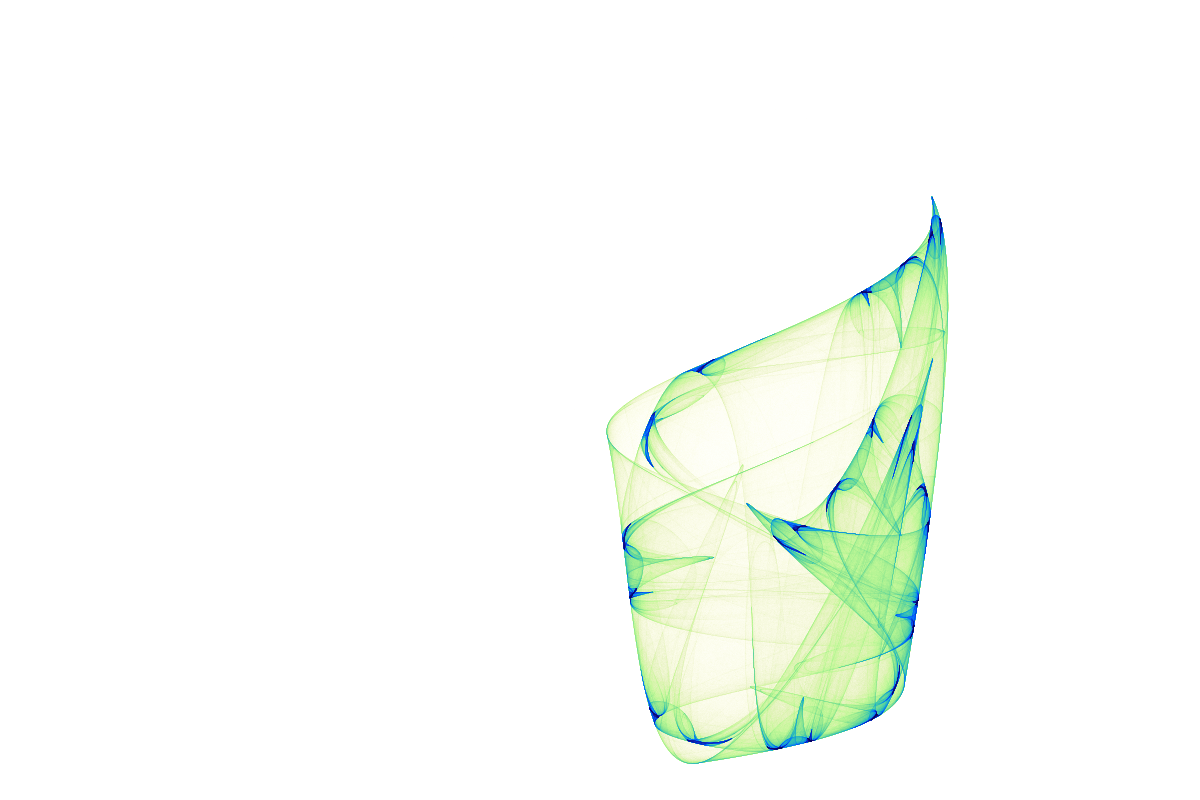
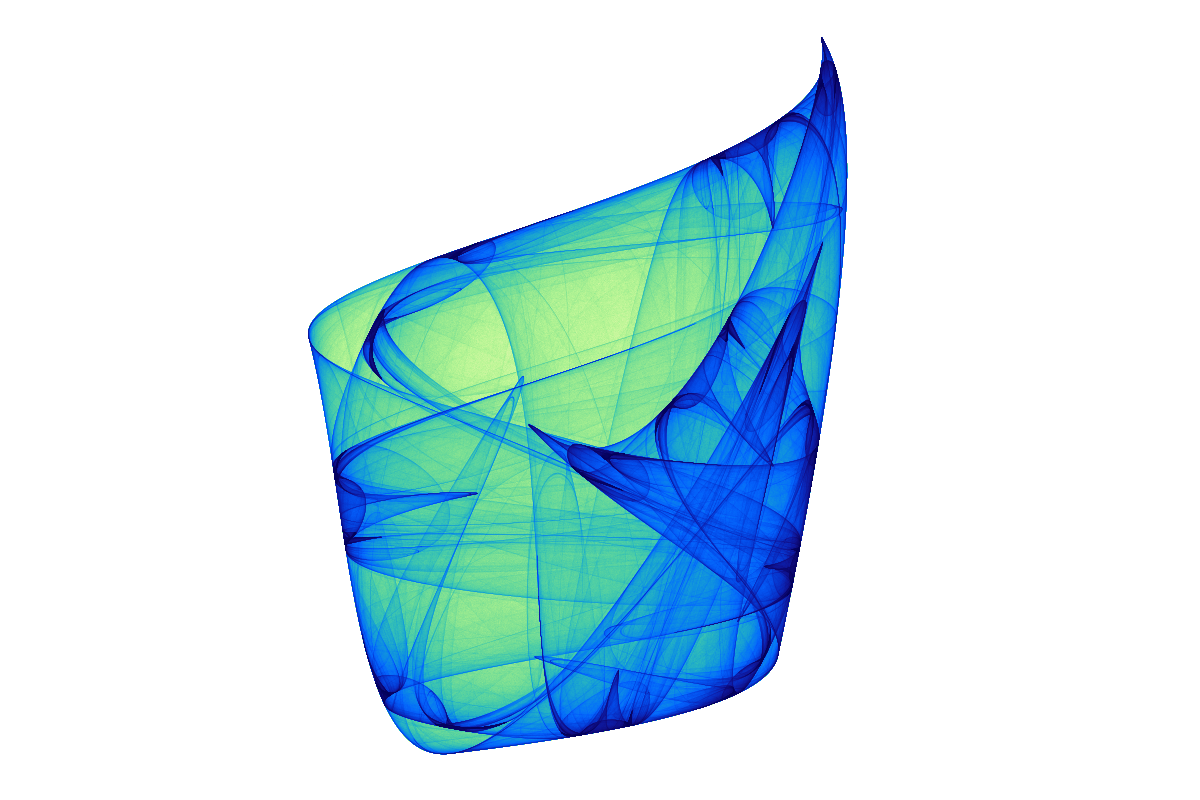

In [ ]:
# @title Example: Tuned Settings
# @markdown This hash does not look good in default parameters,
# @markdown but this can be resolved by fine-tuning the parameters to crop it out.
# @markdown The following parameters are shared:
hash_text = "AQIDBAUGBwgJEBESExQVFgECAwQFBgcICRAREhwWMtwmi9dGKhVgMTKDCk86F-A7bi4zy9sEW0N7nP8HPA-nV2sBP_l27UVxXGyJc7cU8sMVeLuV_7RXBVL_VglIq-0xY0w5_e1GvsusCnCfm9zGXTza8rxgVFyzoUIl8wFajhE79ZXMgpjLGN5axmzntljO6cqz-x6ZtGi2wp_8qYH43HvmuwLX8rMkmxxavNbrFc4tywyzdtjgiCFWS9rsBjWp8yLV3sWflEaiHDEau6HzutdC7aUsAN7oaVmdGcspnitgVGXCte4xJ7R2Jjcy0mFICp0XV6p5Pr-MKEfakHcNKTmzHv4KGsUSUUzgDLFq5ydwP88w43_4yhWcRMsY_9d6LaIuYdBnNcp0G84O4fdOoiWeRDju1h3gXh-z3vY8qaEtFSBvrdwmIDrS5Arzx40WK8_TOnabgnDbmR6e0gg7iBqOUT4zpH5lUyvqzsiat0M7CA6MGlE80dcPzpHUKU1r5bKErjER6sC7lw7TNC0NLPiFv5rp21kzHmgcJ1p0Qe3rEcL7v60yD1TxYVF94rInoMbsoQCo-XaoMkSyEn5LiAISmThxf2wMOHpA34G7kw6GNYMpbQSoxFewk1JdLbcnAJXwj-gMyg==" # @param {type: "string"}
cmap = "inferno" # @param ['Greys', 'Blues', 'Reds', 'Oranges', 'Purples', 'inferno', 'hot', 'afmhot', 'copper', 'viridis', 'gist_earth', 'pink', 'summer', 'winter', 'cool', 'Wistia']
max_iterations = "1000000000" # @param [10000,100000,1000000,10000000,100000000,1000000000]

width = 1200 # @param {type:"integer"}
height = 800 # @param {type:"integer"}
background = "force_white" # @param ["default", "force_white", "force_black"]

reverse_image = True # @param {type:"boolean"}

# @markdown And the following parameters are **NOT** shared - the left uses default settings:

density = 24 # @param {type:"slider", min:0, max:50, step:1}

left_padding = -0.23 # @param {type:"slider", min:-1, max:1, step:0.01}
right_padding = 0.32 # @param {type:"slider", min:-1, max:1, step:0.01}
top_padding = -0.18 # @param {type:"slider", min:-1, max:1, step:0.01}
bottom_padding = 0.05 # @param {type:"slider", min:-1, max:1, step:0.01}

background_color = ""
if background == "force_white":
    background_color = "#FFFFFF"
elif background == "force_black":
    background_color = "#000000"

output_before = render_cover_from_hash(
    hash_text=hash_text,
    max_iterations=100000000,
    output_path=os.path.join(OUTPUT_DIR, "cover_tuned_before.png"),
    width=width,
    height=height,
    left_padding=0.36,
    right_padding=0.36,
    top_padding=0.05,
    bottom_padding=0.05,
    density=15,
    background_color=background_color,
    cmap=cmap,
    flip=reverse_image,
    use_cache=True
)

output_after = render_cover_from_hash(
    hash_text=hash_text.strip(),
    max_iterations=int(max_iterations),
    output_path=os.path.join(OUTPUT_DIR, "cover_tuned_after.png"),
    width=width,
    height=height,
    left_padding=left_padding,
    right_padding=right_padding,
    top_padding=top_padding,
    bottom_padding=bottom_padding,
    density=density,
    background_color=background_color,
    cmap=cmap,
    flip=reverse_image,
    use_cache=True
)

with open(os.path.join(OUTPUT_DIR, "cover_tuned_before.png"), "rb") as f:
    img_bytes_before = f.read()
    img_b64_before = base64.b64encode(img_bytes_before).decode()

with open(os.path.join(OUTPUT_DIR, "cover_tuned_after.png"), "rb") as f:
    img_bytes_after = f.read()
    img_b64_after = base64.b64encode(img_bytes_after).decode()

HTML(f"""
<div style="display:flex; align-items:center; justify-content:center; width:100%; gap:40px;">
  <div style="display:flex; align-items:center; gap:16px;">
    <div style="display:flex; flex-direction:column; align-items:center; min-width:80px; flex-shrink:0;">
      <div style="font-size:22px; font-weight:bold; color:#222; background:white; padding:6px 14px; border-radius:8px; white-space:nowrap;">Before</div>
      <div style="font-size:11px; color:#aaa; margin-top:3px; white-space:nowrap;">(default settings)</div>
    </div>
    <img src="data:image/png;base64,{img_b64_before}"
         style="max-width:30vw; width:auto; height:auto; object-fit:contain; border:1px solid black; outline:1px solid white;">
  </div>
  <div style="display:flex; align-items:center; gap:16px;">
    <div style="display:flex; flex-direction:column; align-items:center; min-width:80px; flex-shrink:0;">
      <div style="font-size:22px; font-weight:bold; color:#222; background:white; padding:6px 14px; border-radius:8px; white-space:nowrap;">After</div>
      <div style="font-size:11px; color:#aaa; margin-top:3px; white-space:nowrap;">(current settings)</div>
    </div>
    <img src="data:image/png;base64,{img_b64_after}"
         style="max-width:30vw; width:auto; height:auto; object-fit:contain; border:1px solid black; outline:1px solid white;">
  </div>
</div>
""")

# Create Images Using Gradio Interface

You can also find the Gradio app here:
https://huggingface.co/spaces/Bojun-Feng/chaos-vis-image-gen

The Gradio interface is laggier, but its UI is nicer.

In [ ]:
#@title Define Gradio CSS

GRADIO_CSS = """
/* ── GLOBAL RESET & DARK BASE ── */
*, *::before, *::after {
  box-sizing: border-box;
}

.gradio-container .main,
.gradio-container .wrap,
.gradio-container .contain,
.gradio-container > div {
  background: transparent !important;
}

body {
  background: #07080f !important;
}

/* Kill all Gradio gray/white wrapper backgrounds */
.gradio-container .block,
.gradio-container .form,
.gradio-container .row,
.gradio-container .col,
.gradio-container .styler,
.gradio-container .padded,
.gradio-container .container,
.gradio-container .prose,
.gradio-container .svelte-1svsvh2,
.gradio-container .svelte-1vd8eap,
.gradio-container .svelte-1xp0cw7,
.gradio-container .svelte-1nguped,
.gradio-container .svelte-lag733,
.gradio-container .svelte-vuh1yp,
.gradio-container .svelte-1jkmaen,
.gradio-container .svelte-7ddecg,
.gradio-container [class*="svelte-"] {
  background: transparent !important;
  background-color: transparent !important;
}
/* Kill all Gradio borders, outlines, and box-shadows on wrappers */
.gradio-container .block,
.gradio-container .form,
.gradio-container .padded,
.gradio-container .container,
.gradio-container .styler,
.gradio-container [class*="svelte-"] {
  border: none !important;
  border-width: 0 !important;
  border-color: transparent !important;
  box-shadow: none !important;
  outline: none !important;
}

/* Reset the inline CSS variable borders Gradio injects */
.gradio-container .styler {
  --block-border-width: 0px !important;
  --button-border-width: 0px !important;
  --form-gap-width: 0px !important;
  --layout-gap: 0px !important;
}

/* Remove the 1px form divider lines between stacked inputs */
.gradio-container .form {
  gap: 0 !important;
  border: none !important;
}

.gradio-container .form > .block {
  border: none !important;
  border-bottom: none !important;
  border-top: none !important;
}

/* Re-apply borders ONLY where you want them */
.cyber-panel {
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
  box-shadow:
    0 0 20px rgba(0, 0, 0, 0.5),
    0 0 10px rgba(0, 255, 200, 0.04),
    inset 0 1px 0 rgba(0, 255, 200, 0.06) !important;
}

.gradio-container .gr-group,
.gradio-container .group {
  border: 1px solid rgba(0, 255, 200, 0.08) !important;
  box-shadow: none !important;
}

.gradio-container input[type="text"],
.gradio-container input[type="number"],
.gradio-container textarea,
.gradio-container select {
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
}

.gradio-container input:focus,
.gradio-container textarea:focus,
.gradio-container select:focus {
  border: 1px solid rgba(0, 255, 200, 0.4) !important;
  box-shadow: 0 0 12px rgba(0, 255, 200, 0.1) !important;
}

#title-bar {
  border: 1px solid rgba(0, 255, 200, 0.2) !important;
  box-shadow:
    0 0 15px rgba(0, 255, 200, 0.07),
    inset 0 1px 0 rgba(0, 255, 200, 0.08) !important;
}

#render-btn {
  border: none !important;
  box-shadow:
    0 0 20px rgba(0, 255, 200, 0.2),
    0 0 40px rgba(0, 180, 216, 0.1) !important;
}

#output-box {
  border: 1px solid rgba(0, 255, 200, 0.1) !important;
}

/* Re-apply dark bg only to actual input fields */
.gradio-container input[type="text"],
.gradio-container input[type="number"],
.gradio-container textarea,
.gradio-container select {
  background: rgba(5, 8, 18, 0.8) !important;
  background-color: rgba(5, 8, 18, 0.8) !important;
}

/* Re-apply panel backgrounds (these are your intentional styled panels) */
.cyber-panel {
  background: linear-gradient(180deg, rgba(10, 14, 24, 0.92), rgba(8, 10, 18, 0.96)) !important;
}

/* Re-apply group backgrounds */
.gradio-container .gr-group,
.gradio-container .group {
  background: rgba(5, 10, 20, 0.4) !important;
}

.gradio-container {
  background: #07080f !important;
  background-color: #07080f !important;
  color: #e0e6f0 !important;
  font-family: 'Inter', 'Segoe UI', system-ui, -apple-system, sans-serif !important;
  min-height: 100vh;
}

/* Subtle grid pattern overlay */
.gradio-container::before {
  content: '';
  position: fixed;
  inset: 0;
  background:
    linear-gradient(rgba(0, 255, 200, 0.015) 1px, transparent 1px),
    linear-gradient(90deg, rgba(0, 255, 200, 0.015) 1px, transparent 1px);
  background-size: 40px 40px;
  pointer-events: none;
  z-index: 0;
}

/* Radial glow accents */
.gradio-container::after {
  content: '';
  position: fixed;
  inset: 0;
  background:
    radial-gradient(ellipse 600px 400px at 10% 10%, rgba(0, 255, 200, 0.06), transparent),
    radial-gradient(ellipse 500px 500px at 90% 80%, rgba(255, 0, 120, 0.05), transparent),
    radial-gradient(ellipse 400px 300px at 50% 0%, rgba(100, 120, 255, 0.04), transparent);
  pointer-events: none;
  z-index: 0;
}

/* Make content sit above overlays */
.gradio-container > * {
  position: relative;
  z-index: 1;
}

/* ── TITLE BAR ── */
#title-bar {
  margin: 0 0 10px 0 !important;
  padding: 14px 20px !important;
  background: linear-gradient(135deg, rgba(10, 12, 22, 0.95), rgba(15, 18, 30, 0.9)) !important;
  border: 1px solid rgba(0, 255, 200, 0.2) !important;
  border-radius: 12px !important;
  box-shadow:
    0 0 15px rgba(0, 255, 200, 0.07),
    inset 0 1px 0 rgba(0, 255, 200, 0.08) !important;
  text-align: left;
}

#title-bar h1 {
  margin: 0 !important;
  padding: 0 !important;
  font-size: 22px !important;
  font-weight: 800 !important;
  letter-spacing: 0.1em !important;
  text-transform: uppercase !important;
  background: linear-gradient(90deg, #00ffc8, #00b4d8 40%, #ff006e 100%) !important;
  -webkit-background-clip: text !important;
  -webkit-text-fill-color: transparent !important;
  background-clip: text !important;
  line-height: 1.3 !important;
}

#title-bar p {
  margin: 2px 0 0 0 !important;
  padding: 0 !important;
  font-size: 11px !important;
  color: #5a7a8a !important;
  letter-spacing: 0.15em !important;
  text-transform: uppercase !important;
}

/* ── PANEL CARDS ── */
.cyber-panel {
  background: linear-gradient(180deg, rgba(10, 14, 24, 0.92), rgba(8, 10, 18, 0.96)) !important;
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
  border-radius: 14px !important;
  padding: 16px !important;
  box-shadow:
    0 0 20px rgba(0, 0, 0, 0.5),
    0 0 10px rgba(0, 255, 200, 0.04),
    inset 0 1px 0 rgba(0, 255, 200, 0.06) !important;
}

/* ── SECTION HEADERS ── */
.section-label {
  font-size: 10px !important;
  letter-spacing: 0.2em !important;
  text-transform: uppercase !important;
  color: #00ffc8 !important;
  font-weight: 700 !important;
  margin: 0 0 6px 2px !important;
  padding: 0 !important;
  line-height: 1 !important;
  text-shadow: 0 0 12px rgba(0, 255, 200, 0.3) !important;
}

.section-label span {
  color: #00ffc8 !important;
}

/* ── GENERAL BLOCK OVERRIDES ── */
.gradio-container .block {
  background: transparent !important;
  border: none !important;
  border-radius: 10px !important;
  padding: 0 !important;
}

/* ── ALL FORM LABELS ── */
.gradio-container label,
.gradio-container .label-wrap span,
.gradio-container .gr-form .wrap .label {
  color: #6b8a99 !important;
  font-size: 10px !important;
  font-weight: 600 !important;
  text-transform: uppercase !important;
  letter-spacing: 0.1em !important;
}

/* ── TEXT INPUTS & TEXTAREAS ── */
.gradio-container input[type="text"],
.gradio-container input[type="number"],
.gradio-container textarea,
.gradio-container .wrap input,
.gradio-container .wrap textarea {
  background: rgba(5, 8, 18, 0.8) !important;
  color: #c8dce8 !important;
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
  border-radius: 8px !important;
  font-family: 'JetBrains Mono', 'Fira Code', ui-monospace, monospace !important;
  font-size: 13px !important;
  transition: border-color 0.2s, box-shadow 0.2s !important;
}

.gradio-container input:focus,
.gradio-container textarea:focus {
  border-color: rgba(0, 255, 200, 0.4) !important;
  box-shadow: 0 0 12px rgba(0, 255, 200, 0.1) !important;
  outline: none !important;
}

/* ── HASH BOX ── */
#hash-box textarea {
  min-height: 40px !important;
  max-height: 40px !important;
  line-height: 1.2 !important;
  padding: 10px 12px !important;
  resize: none !important;
}

/* ── DROPDOWNS ── */
.gradio-container .wrap.svelte-1kyjfya,
.gradio-container .secondary-wrap,
.gradio-container .wrap[data-testid] {
  background: rgba(5, 8, 18, 0.8) !important;
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
  border-radius: 8px !important;
}

.gradio-container .wrap.svelte-1kyjfya input,
.gradio-container .secondary-wrap input {
  color: #c8dce8 !important;
}

/* Dropdown list */
.gradio-container ul[role="listbox"],
.gradio-container .dropdown-menu,
.gradio-container ul.options {
  background: #0a0e1a !important;
  border: 1px solid rgba(0, 255, 200, 0.15) !important;
  border-radius: 8px !important;
  box-shadow: 0 8px 30px rgba(0, 0, 0, 0.6) !important;
}

.gradio-container ul[role="listbox"] li,
.gradio-container .dropdown-menu li,
.gradio-container ul.options li {
  color: #a0b8c8 !important;
}

.gradio-container ul[role="listbox"] li:hover,
.gradio-container ul[role="listbox"] li.selected,
.gradio-container .dropdown-menu li:hover {
  background: rgba(0, 255, 200, 0.1) !important;
  color: #00ffc8 !important;
}

/* ── NUMBER INPUTS ── */
.gradio-container input[type="number"] {
  background: rgba(5, 8, 18, 0.8) !important;
  color: #c8dce8 !important;
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
  border-radius: 8px !important;
}

/* ── SLIDERS ── */
.gradio-container input[type="range"] {
  accent-color: #00ffc8 !important;
}

.gradio-container .range-slider input[type="number"] {
  background: rgba(5, 8, 18, 0.9) !important;
  color: #c8dce8 !important;
  border: 1px solid rgba(0, 255, 200, 0.12) !important;
}

/* ── CHECKBOX ── */
.gradio-container input[type="checkbox"] {
  accent-color: #00ffc8 !important;
}

.gradio-container .gr-check-radio label {
  color: #8aa0b0 !important;
}

/* ── RENDER BUTTON ── */
#render-btn {
  background: linear-gradient(135deg, #00ffc8 0%, #00b4d8 50%, #006eff 100%) !important;
  border: none !important;
  color: #030a08 !important;
  font-weight: 800 !important;
  font-size: 13px !important;
  letter-spacing: 0.14em !important;
  text-transform: uppercase !important;
  padding: 10px 24px !important;
  border-radius: 8px !important;
  box-shadow:
    0 0 20px rgba(0, 255, 200, 0.2),
    0 0 40px rgba(0, 180, 216, 0.1) !important;
  transition: all 0.2s ease !important;
  cursor: pointer !important;
}

#render-btn:hover {
  filter: brightness(1.1) !important;
  box-shadow:
    0 0 25px rgba(0, 255, 200, 0.3),
    0 0 50px rgba(0, 180, 216, 0.15) !important;
  transform: translateY(-1px) !important;
}

#render-btn:active {
  transform: translateY(0) !important;
  filter: brightness(0.95) !important;
}

/* ── OUTPUT IMAGE ── */
#output-box {
  background: rgba(5, 8, 18, 0.6) !important;
  border: 1px solid rgba(0, 255, 200, 0.1) !important;
  border-radius: 10px !important;
  overflow: hidden !important;
}

#output-box img {
  border-radius: 8px !important;
}

/* ── GROUP STYLING ── */
.gradio-container .gr-group,
.gradio-container .group {
  background: rgba(5, 10, 20, 0.4) !important;
  border: 1px solid rgba(0, 255, 200, 0.08) !important;
  border-radius: 10px !important;
  padding: 10px !important;
  margin-bottom: 6px !important;
}

/* ── COMPACT SPACING ── */
.compact-gap {
  gap: 10px !important;
}

.tight-col > .block,
.tight-col > div {
  margin-bottom: 2px !important;
  padding-bottom: 0 !important;
}

.tight-col .gr-group,
.tight-col .group {
  margin-bottom: 6px !important;
}

/* ── SCROLLBAR ── */
::-webkit-scrollbar {
  width: 6px;
  height: 6px;
}

::-webkit-scrollbar-track {
  background: #07080f;
}

::-webkit-scrollbar-thumb {
  background: rgba(0, 255, 200, 0.15);
  border-radius: 3px;
}

::-webkit-scrollbar-thumb:hover {
  background: rgba(0, 255, 200, 0.3);
}

/* ── HIDE FOOTER ── */
footer {
  display: none !important;
}

/* ── FIX GRADIO DARK OVERRIDES ── */
.gradio-container .gr-box {
  background: transparent !important;
  border: none !important;
}

.gradio-container .gr-padded {
  padding: 0 !important;
}

.gradio-container .gr-form {
  background: transparent !important;
  border: none !important;
}

/* Ensure all text on dark bg is light */
.gradio-container span,
.gradio-container p,
.gradio-container div {
  color: inherit;
}

/* Fix Markdown rendered inside panels */
.gradio-container .md h3,
.gradio-container .prose h3,
.gradio-container .markdown-text h3 {
  color: #00ffc8 !important;
  font-size: 10px !important;
  letter-spacing: 0.2em !important;
  text-transform: uppercase !important;
  font-weight: 700 !important;
  margin: 0 0 4px 0 !important;
  text-shadow: 0 0 12px rgba(0, 255, 200, 0.3) !important;
}

.gradio-container .md strong,
.gradio-container .prose strong {
  color: #ff006e !important;
  font-size: 10px !important;
  letter-spacing: 0.12em !important;
  text-transform: uppercase !important;
  text-shadow: 0 0 8px rgba(255, 0, 110, 0.2) !important;
}

/* Reverse Image checkbox - make it a toggle button style */
.gradio-container input[type="checkbox"] {
  appearance: none !important;
  -webkit-appearance: none !important;
  width: 40px !important;
  height: 22px !important;
  background: rgba(255, 0, 110, 0.15) !important;
  border: 2px solid rgba(255, 0, 110, 0.4) !important;
  border-radius: 12px !important;
  position: relative !important;
  cursor: pointer !important;
  transition: all 0.3s ease !important;
  vertical-align: middle !important;
}

.gradio-container input[type="checkbox"]::after {
  content: '' !important;
  position: absolute !important;
  top: 2px !important;
  left: 2px !important;
  width: 14px !important;
  height: 14px !important;
  background: #ff006e !important;
  border-radius: 50% !important;
  transition: all 0.3s ease !important;
  opacity: 0.5 !important;
  box-shadow: none !important;
}

.gradio-container input[type="checkbox"]:checked {
  background: rgba(0, 255, 200, 0.2) !important;
  border-color: #00ffc8 !important;
  box-shadow:
    0 0 12px rgba(0, 255, 200, 0.3),
    0 0 30px rgba(0, 255, 200, 0.1) !important;
}

.gradio-container input[type="checkbox"]:checked::after {
  left: 20px !important;
  background: #00ffc8 !important;
  opacity: 1 !important;
  box-shadow: 0 0 8px rgba(0, 255, 200, 0.6) !important;
}

/* Make the checkbox label text react too */
.gradio-container input[type="checkbox"] + span,
.gradio-container input[type="checkbox"] ~ span {
  color: #5a4050 !important;
  transition: all 0.3s ease !important;
}

.gradio-container input[type="checkbox"]:checked + span,
.gradio-container input[type="checkbox"]:checked ~ span {
  color: #00ffc8 !important;
  text-shadow: 0 0 10px rgba(0, 255, 200, 0.3) !important;
}

/* Remove inner outline on dropdown listbox inputs */
.gradio-container input[role="listbox"],
.gradio-container input.svelte-1hfxrpf {
  border: none !important;
  outline: none !important;
  box-shadow: none !important;
  background: transparent !important;
}

.gradio-container input[role="listbox"]:focus,
.gradio-container input.svelte-1hfxrpf:focus {
  border: none !important;
  outline: none !important;
  box-shadow: none !important;
}

/* ── MOBILE RESPONSIVE ── */
@media (max-width: 768px) {
  #title-bar h1 {
    font-size: 16px !important;
  }
}
"""

<IPython.core.display.Javascript object>

In [ ]:
# @title Define Helper Function

def render_image(
    hash_text,
    cmap,
    max_iterations,
    width,
    height,
    background,
    density,
    left_padding,
    right_padding,
    top_padding,
    bottom_padding,
    reverse_image
):
    background_color = ""
    if background == "force_white":
        background_color = "#FFFFFF"
    elif background == "force_black":
        background_color = "#000000"

    output_path = os.path.join(OUTPUT_DIR, "cover.png")

    render_cover_from_hash(
        hash_text=hash_text.strip(),
        max_iterations=int(max_iterations),
        output_path=output_path,
        width=int(width),
        height=int(height),
        left_padding=float(left_padding),
        right_padding=float(right_padding),
        top_padding=float(top_padding),
        bottom_padding=float(bottom_padding),
        density=int(density),
        background_color=background_color,
        cmap=cmap,
        flip=reverse_image,
        use_cache=True
    )

    return Image.open(output_path)

def launch_ui(
    hash_text,
    cmap,
    max_iterations,
    width,
    height,
    background,
    density,
    left_padding,
    right_padding,
    top_padding,
    bottom_padding,
    reverse_image,
    css
):
    warnings.filterwarnings("ignore", category=DeprecationWarning, module=r"gradio\..*")
    warnings.filterwarnings("ignore", message=r".*parameter in the Blocks constructor.*")
    logging.getLogger("gradio").setLevel(logging.ERROR)
    logging.getLogger("httpx").setLevel(logging.ERROR)

    with gr.Blocks(css=css, fill_height=True, theme=gr.themes.Base()) as demo:
        with gr.Column(elem_id="app-shell"):
            gr.HTML("""
            <div id="title-bar">
              <h1>⬡ Chaos Vis - Image Gen Interface</h1>
              <p>Visualize Random Attractors</p>
            </div>
            """)

            with gr.Row(equal_height=True, elem_classes=["compact-gap"]):
                # ── LEFT: Input + Output ──
                with gr.Column(scale=11, min_width=540, elem_classes=["cyber-panel"]):
                    gr.Markdown("### ◈ Input · Paste a hash from [@bo_is_coding](https://instagram.com/bo_is_coding)")

                    hash_text_box = gr.Textbox(
                        value=hash_text,
                        label="Hash",
                        lines=1,
                        max_lines=1,
                        elem_id="hash-box",
                        container=True
                    )

                    render_button = gr.Button("◆ Render", variant="primary", elem_id="render-btn")

                    output_image = gr.Image(
                        value="https://www.fengbojun.com/static/images/apps/chaos-vis-image-gen/gradio-app-placeholder.webp",
                        label="Output",
                        type="pil",
                        height=430,
                        elem_id="output-box"
                    )

                # ── RIGHT: Controls ──
                with gr.Column(scale=9, min_width=400, elem_classes=["cyber-panel", "tight-col"]):
                    gr.Markdown("### ◈ Controls")

                    with gr.Group():
                        gr.Markdown("**Canvas**")
                        with gr.Row():
                            width_input = gr.Number(value=width, label="Width", precision=0)
                            height_input = gr.Number(value=height, label="Height", precision=0)

                    with gr.Group():
                        gr.Markdown("**Style**")
                        with gr.Row():
                            background_input = gr.Dropdown(
                                choices=["default", "force_white", "force_black"],
                                value=background,
                                label="Background"
                            )
                            cmap_input = gr.Dropdown(
                                choices=[
                                    "Greys", "Blues", "Reds", "Oranges", "Purples", "inferno",
                                    "hot", "afmhot", "copper", "viridis", "gist_earth",
                                    "pink", "summer", "winter", "cool", "Wistia"
                                ],
                                value=cmap,
                                label="Colormap"
                            )

                    with gr.Group():
                        gr.Markdown("**Render**")
                        with gr.Row():
                            max_iterations_input = gr.Dropdown(
                                choices=[10000, 100000, 1000000, 10000000, 100000000, 1000000000],
                                value=int(max_iterations),
                                label="Max Iterations"
                            )
                            density_input = gr.Slider(
                                minimum=0,
                                maximum=50,
                                step=1,
                                value=density,
                                label="Density"
                            )
                        reverse_image_input = gr.Checkbox(
                            value=reverse_image,
                            label="Reverse Image"
                        )

                    with gr.Group():
                        gr.Markdown("**Padding**")
                        with gr.Row():
                            left_padding_input = gr.Slider(
                                minimum=-1, maximum=1, step=0.01,
                                value=left_padding, label="Left"
                            )
                            right_padding_input = gr.Slider(
                                minimum=-1, maximum=1, step=0.01,
                                value=right_padding, label="Right"
                            )
                        with gr.Row():
                            top_padding_input = gr.Slider(
                                minimum=-1, maximum=1, step=0.01,
                                value=top_padding, label="Top"
                            )
                            bottom_padding_input = gr.Slider(
                                minimum=-1, maximum=1, step=0.01,
                                value=bottom_padding, label="Bottom"
                            )

        render_button.click(
            fn=render_image,
            inputs=[
                hash_text_box,
                cmap_input,
                max_iterations_input,
                width_input,
                height_input,
                background_input,
                density_input,
                left_padding_input,
                right_padding_input,
                top_padding_input,
                bottom_padding_input,
                reverse_image_input
            ],
            outputs=output_image
        )

    demo.launch(share=True, quiet=True)

    # Force the Gradio iframe to expand to full content height in Colab
    display(Javascript('''
        google.colab.output.setIframeHeight(0, true, {maxHeight: 5000});

        // Also resize the Gradio iframe specifically
        const resizeGradio = () => {
            const iframes = document.querySelectorAll('iframe');
            iframes.forEach(iframe => {
                iframe.style.height = '900px';
                iframe.style.minHeight = '900px';
                iframe.style.maxHeight = 'none';
            });
            // Remove any scroll containers Colab wraps around output
            document.querySelectorAll('.output_scroll, .output_subarea').forEach(el => {
                el.style.maxHeight = 'none';
                el.style.overflow = 'visible';
            });
        };
        resizeGradio();
        // Re-run after a delay since Gradio iframe loads async
        setTimeout(resizeGradio, 2000);
        setTimeout(resizeGradio, 5000);
    '''))

<IPython.core.display.Javascript object>

In [ ]:
# @title Launch Gradio Interface with Default Values

hash_text = "AQIDBAUGBwgJEBESExQVFgECAwQFBgcICRAREtT7Uvq9jkUEsEMVYLWQTLY6F-A7bi4zy9sEW0N7nP8HPA-nV2sBP_l27UVxXGyJc7cU8sMVeLuV_7RXBVL_VglIq-0xY0w5_e1GvsusCnCfm9zGXTza8rxgVFyzoUIl8wFajhE79ZXMgpjLGN5axmzntljO6cqz-x5f0NYpdNeyqYH43HvmuwLX8rMkK1tkfT1-e04tywyzdtjgiCFWS1I1TflsMy3V3sWflEaiHDEau6FDCMq9PHEXAN7oaVmdGcspnitgyGo493wfH7R2Jjcy0mFICp0XV1jd4rBzE3PakHcNKTmzHv4KGsWSEt0CEYNKZydwP88w43_4yhWcQnwCjjpLJiIuYdBnNcp0G84O4e3ZqM8I-THu1h3gXh-z3vY8qaHLJIiwnTgDoDrS5Arzx40WK8_TQvP8O7Zemh6e0gg7iBqOUT4zpKD8-5wsRLwat0M7CA6MGlE80de56Vl-4LNt5bKErjER6sC7lw7TzFKa_nA0zprp21kzHmgcJ1p0QZa4ilF3hOAyD1TxYVF94rInoMbSTf4O7oynMkSyEn5LiAISmThxBJ93NwC-5oG7kw6GNYMpbQSoxM8QaVTLcr4nAJXwj-gMyg==" # @param {type: "string"}
cmap = "inferno" # @param ['Greys', 'Blues', 'Reds', 'Oranges', 'Purples', 'inferno', 'hot', 'afmhot', 'copper', 'viridis', 'gist_earth', 'pink', 'summer', 'winter', 'cool', 'Wistia']
max_iterations = "100000000" # @param [10000,100000,1000000,10000000,100000000,1000000000]

width = 2400 # @param {type:"integer"}
height = 1600 # @param {type:"integer"}
background = "default" # @param ["default", "force_white", "force_black"]
density = 15 # @param {type:"slider", min:0, max:50, step:1}

left_padding = 0.36 # @param {type:"slider", min:-1, max:1, step:0.01}
right_padding = 0.36 # @param {type:"slider", min:-1, max:1, step:0.01}
top_padding = 0.05 # @param {type:"slider", min:-1, max:1, step:0.01}
bottom_padding = 0.05 # @param {type:"slider", min:-1, max:1, step:0.01}

reverse_image = False # @param {type:"boolean"}

background_color = ""
if background == "force_white":
    background_color = "#FFFFFF"
elif background == "force_black":
    background_color = "#000000"

launch_ui(
    hash_text=hash_text,
    cmap=cmap,
    max_iterations=max_iterations,
    width=width,
    height=height,
    background=background,
    density=density,
    left_padding=left_padding,
    right_padding=right_padding,
    top_padding=top_padding,
    bottom_padding=bottom_padding,
    reverse_image=reverse_image,
    css=GRADIO_CSS
)

<IPython.core.display.Javascript object>

* Running on public URL: https://25fddc5e89a484c7a1.gradio.live


<IPython.core.display.Javascript object>